In [11]:
## 0 – Environment setup

In [4]:
import os, sys

# ── Workspace roots ───────────────────────────────────────────────────────────
# This notebook lives at the repo root, so REPO_ROOT = os.getcwd().
# Mirror the pattern used in benchmark_tome.py:
#   sys.path.insert(0, os.path.join(os.path.dirname(__file__), 'sam-hq'))
REPO_ROOT   = os.getcwd()            # /media/volume/Chau/SAM_Quantization
SAM_ROOT    = os.path.join(REPO_ROOT, 'sam-hq')
PITOME_ROOT = os.path.join(REPO_ROOT, 'PiToMe')

for p in [SAM_ROOT, PITOME_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

print('REPO_ROOT   :', REPO_ROOT)
print('SAM_ROOT    :', SAM_ROOT)
print('PITOME_ROOT :', PITOME_ROOT)


REPO_ROOT   : /media/volume/Chau/SAM_Quantization
SAM_ROOT    : /media/volume/Chau/SAM_Quantization/sam-hq
PITOME_ROOT : /media/volume/Chau/SAM_Quantization/PiToMe


## 1 – Load SAM model

In [5]:
import copy, cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from segment_anything import sam_model_registry

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_TYPE = 'vit_l'
CKPT_PATH  = os.path.join(REPO_ROOT, 'ckts', 'sam_hq_vit_l.pth')
image = 'dog.jpg'
IMG_PATH   = os.path.join(REPO_ROOT, 'input_imgs',image)

sam = sam_model_registry[MODEL_TYPE](checkpoint=CKPT_PATH).to(DEVICE)
sam.eval()

# ── Preprocess calibration image once; reused by patch + heatmap ──────────────
IMG_SIZE  = sam.image_encoder.img_size   # 1024
_mean     = torch.tensor([123.675, 116.28, 103.53], device=DEVICE, dtype=torch.float16)[:, None, None]
_std      = torch.tensor([58.395,  57.12,  57.375],  device=DEVICE, dtype=torch.float16)[:, None, None]

img_rgb    = cv2.imread(IMG_PATH)[:, :, ::-1]
img_rgb    = np.ascontiguousarray(img_rgb)
img_tensor = (torch.from_numpy(cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)))
              .permute(2, 0, 1).unsqueeze(0).float().to(DEVICE).half()
              .sub_(_mean).div_(_std))   # (1, 3, 1024, 1024)  fp16

n_blocks = len(sam.image_encoder.blocks)
n_global = sum(1 for blk in sam.image_encoder.blocks if blk.window_size == 0)
print(f'Loaded SAM-HQ {MODEL_TYPE}  |  {n_blocks} blocks ({n_global} global, {n_blocks-n_global} local)')

/media/volume/Chau/miniconda3/envs/sam/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/volume/Chau/miniconda3/envs/sam/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/media/volume/Chau/miniconda3/envs/sam/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/media/volume/Chau/SAM_Quantization/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_5m_

<All keys matched successfully>
Loaded SAM-HQ vit_l  |  24 blocks (4 global, 20 local)


## 2 – Apply channel_sort_sam patch

In [6]:
from algo.sparsesam.patch.channel_sort_sam import apply_patch as channel_sort_sam

SORT_BY = 'std'   # 'std' or 'magnitude'

sam_cs = copy.deepcopy(sam)
sam_cs.image_encoder = sam_cs.image_encoder.half()
sam_cs.image_encoder = channel_sort_sam(
    sam_cs.image_encoder,
    calib_images=img_tensor,   # use the real image for accurate calibration
    sort_by=SORT_BY,
    inplace=True,
    apply_tome=False,
)
sam_cs.eval()

sort_idx  = sam_cs.image_encoder.channel_sort_info['sort_idx']
inv_idx   = sam_cs.image_encoder.channel_sort_info['inv_idx']
ch_metric = sam_cs.image_encoder.channel_sort_info['ch_metric']
print(f'sort_by={SORT_BY!r}  sort_idx[:5]={sort_idx[:5].tolist()}')

[Hook-SAM] registered pre-hooks  capture=['block']  blocks=24 (global=4  local=20)  handles=24


[ChannelSort-SAM] sort_by='std'  C=1024  metric range [0.7212, 15.0180]  top-3 orig channels: [927, 684, 110]
[ChannelSort-SAM] channel permutation applied.
[ChannelSort-SAM] MLP hidden permutation applied (24 blocks).
sort_by='std'  sort_idx[:5]=[927, 684, 110, 150, 743]


## 3 – Segmentation correctness check

Run both the original and channel-sorted SAM on a real image with the same point prompt.
Outputs must be bit-for-bit (or float-precision) identical since the permutation is an exact weight equivalence.

[3]
  mask[0]  orig=0.9263  cs=0.9263  IoU=0.998923 <- best


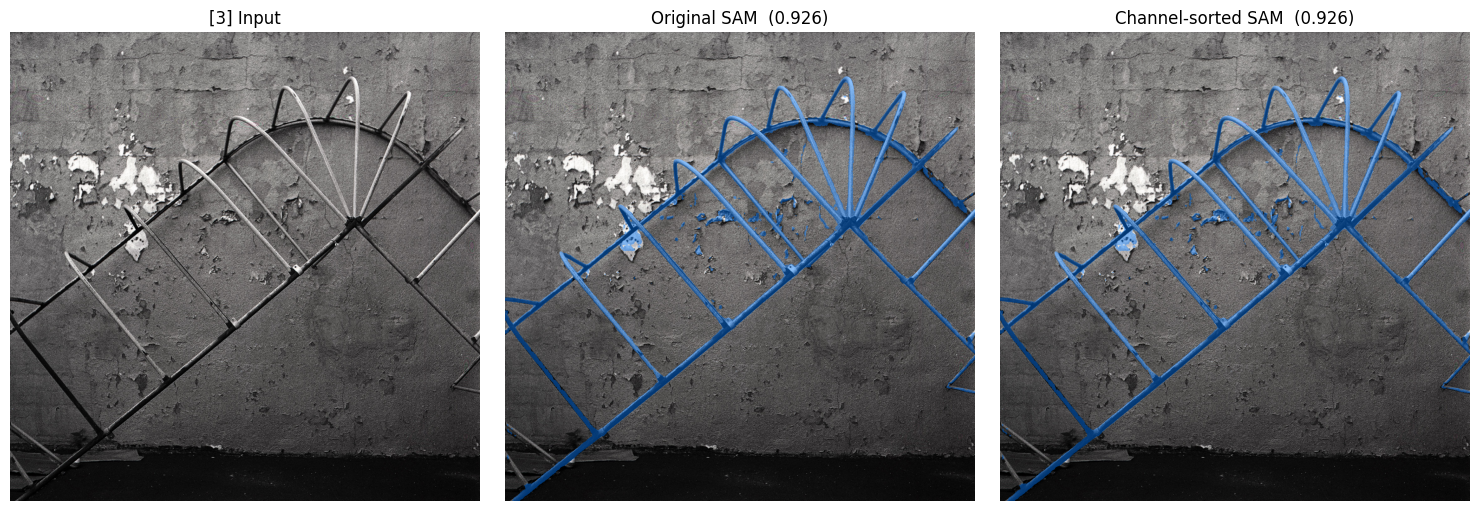

In [7]:
from segment_anything import SamPredictor
from algo.sparsesam.patch.channel_sort_sam import _apply_channel_permutation, _apply_hq_decoder_permutation

# ── Build fp32 channel-sorted model (reuse sort_idx from cell 2) ──────────────
sam_orig_cmp = copy.deepcopy(sam)

sam_cs_cmp = copy.deepcopy(sam)
_apply_channel_permutation(sam_cs_cmp.image_encoder, sort_idx.to(DEVICE))
_apply_hq_decoder_permutation(sam_cs_cmp.mask_decoder, sort_idx.to(DEVICE))
sam_cs_cmp.eval()

# ── Prompts from sam-hq/demo/demo_hqsam.py ───────────────────────────────────
PROMPTS = {
    0: dict(box=np.array([[4, 13, 1007, 1023]]),   point=None, label=None, hq_only=False),
    1: dict(box=np.array([[306, 132, 925, 893]]),   point=None, label=None, hq_only=True),
    2: dict(box=None, point=np.array([[495, 518],[217, 140]]),
            label=np.ones(2), hq_only=True),
    3: dict(box=None, point=np.array([[221, 482],[498, 633],[750, 379]]),
            label=np.ones(3), hq_only=False),
    4: dict(box=np.array([[64, 76, 940, 919]]),     point=None, label=None, hq_only=True),
    5: dict(box=None, point=np.array([[373, 363],[452, 575]]),
            label=np.ones(2), hq_only=False),
    6: dict(box=np.array([[181, 196, 757, 495]]),   point=None, label=None, hq_only=False),
    7: dict(box=None, point=None, label=None, hq_only=False),  # multi-box, skip
}
IMG_DIR = os.path.join(SAM_ROOT, 'demo', 'input_imgs')

def predict(model, img_rgb, box, point, label, hq_only):
    pred = SamPredictor(model)
    pred.set_image(img_rgb)
    masks, scores, _ = pred.predict(
        point_coords=point,
        point_labels=label,
        box=box,
        multimask_output=True,
        hq_token_only=hq_only,
    )
    return masks, scores

def overlay(img, mask, color=(0, 120, 255), alpha=0.45):
    out = img.copy().astype(float)
    out[mask] = out[mask] * (1 - alpha) + np.array(color) * alpha
    return out.astype(np.uint8)

# ── Run comparison on all images ──────────────────────────────────────────────
for idx in range(3,4):
    p = PROMPTS[idx]
    if p['box'] is None and p['point'] is None:
        print(f"[{idx}] skipped (multi-box not supported here)")
        continue

    img_path = os.path.join(IMG_DIR, f'example{idx}.png')
    img_bgr  = cv2.imread(img_path)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    masks_orig, scores_orig = predict(sam_orig_cmp.half(), img_rgb, p['box'], p['point'], p['label'], p['hq_only'])
    masks_cs,   scores_cs   = predict(sam_cs_cmp.half(),   img_rgb, p['box'], p['point'], p['label'], p['hq_only'])

    best = np.argmax(scores_orig)
    print(f"[{idx}]")
    for i in range(len(masks_orig)):
        intersection = (masks_orig[i] & masks_cs[i]).sum()
        union        = (masks_orig[i] | masks_cs[i]).sum()
        iou  = intersection / union if union > 0 else 1.0
        tag  = "\u2713 identical" if np.array_equal(masks_orig[i], masks_cs[i]) else f"IoU={iou:.6f}"
        best_mark = " <- best" if i == best else ""
        print(f"  mask[{i}]  orig={scores_orig[i]:.4f}  cs={scores_cs[i]:.4f}  {tag}{best_mark}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_rgb);                            axes[0].set_title(f'[{idx}] Input')
    axes[1].imshow(overlay(img_rgb, masks_orig[best])); axes[1].set_title(f'Original SAM  ({scores_orig[best]:.3f})')
    axes[2].imshow(overlay(img_rgb, masks_cs[best]));   axes[2].set_title(f'Channel-sorted SAM  ({scores_cs[best]:.3f})')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()


## 4 – Block input heatmap (channel-sorted encoder)

Tokens in Hilbert order × channels sorted high→low std.
Left bar: per-4×4-Hilbert-group token variance. Bottom bars: channel std and magnitude.

In [9]:
from algo.sparsesam.patch.hook import apply_patch as hook
from algo.sparsesam.hilbert_utils import get_hilbert_order, get_hilbert_inverse

# img_tensor already built in cell 1; reuse it here
_enc = hook(sam_cs.image_encoder, capture=('block',))
with torch.no_grad():
    _enc(img_tensor)
block_inputs_cs = _enc.hook_info['block_inputs']   # list of (1,H,W,C) on CPU
_enc.hook_info['remove']()
print(f'Captured {len(block_inputs_cs)} blocks, shape: {tuple(block_inputs_cs[0].shape)}')

[Hook-SAM] registered pre-hooks  capture=['block']  blocks=24 (global=4  local=20)  handles=24
Captured 24 blocks, shape: (1, 64, 64, 1024)


## 5 – MLP linear-layer input distributions (all blocks)

Captures the input to **lin1** (= MLP input after norm2, shape `(B, N, C)`) and
**lin2** (= after GELU, shape `(B, N, mlp_dim)`) for every transformer block,
then plots per-block and per-channel statistics.

In [10]:
# ── Register hooks on lin1 and lin2 of every MLP block ───────────────────────
lin1_inputs = []   # list of (B, N, C)      – one per block
lin2_inputs = []   # list of (B, N, mlp_dim) – one per block

handles = []
for blk in sam_cs.image_encoder.blocks:
    def _make_hook(store):
        def _h(module, args):
            if args:
                store.append(args[0].detach().cpu())
        return _h
    handles.append(blk.mlp.lin1.register_forward_pre_hook(_make_hook(lin1_inputs)))
    handles.append(blk.mlp.lin2.register_forward_pre_hook(_make_hook(lin2_inputs)))

with torch.no_grad():
    sam_cs.image_encoder(img_tensor)

for h in handles:
    h.remove()

print(f"lin1 inputs: {len(lin1_inputs)} blocks, shape {tuple(lin1_inputs[0].shape)}")
print(f"lin2 inputs: {len(lin2_inputs)} blocks, shape {tuple(lin2_inputs[0].shape)}")

lin1 inputs: 24 blocks, shape (1, 64, 64, 1024)
lin2 inputs: 24 blocks, shape (1, 64, 64, 4096)


## 6 – Attention map visualization (local window heads vs global heads)

Patches each `Attention.forward` to capture the softmax attention tensor, then visualizes:
- **Local blocks** (window attention, win=14): all 16 heads within a selected window
- **Global blocks** (full-image attention): all 16 heads over the 64×64 token grid
- **Overlay** on the input image for intuitive interpretation

In [11]:
# ── Attention capture infrastructure ─────────────────────────────────────────
from types import SimpleNamespace
from segment_anything.modeling.image_encoder import add_decomposed_rel_pos

_attn_store = {}   # block_idx → SimpleNamespace(attn, B, nh, H, W)
_fw_originals = {}

def _make_capture_forward(attn_mod, block_idx):
    """
    Replaces Attention.forward to intercept the softmax attn tensor.
    Mirrors the original forward exactly; only adds a side-effect store.
    """
    def forward(x):
        B, H, W, _ = x.shape
        nh = attn_mod.num_heads
        qkv = attn_mod.qkv(x).reshape(B, H * W, 3, nh, -1).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.reshape(3, B * nh, H * W, -1).unbind(0)   # (B*nh, HW, hd)

        attn = (q * attn_mod.scale) @ k.transpose(-2, -1)         # (B*nh, HW, HW)
        if attn_mod.use_rel_pos:
            attn = add_decomposed_rel_pos(
                attn, q, attn_mod.rel_pos_h, attn_mod.rel_pos_w, (H, W), (H, W)
            )
        attn = attn.softmax(dim=-1)

        # Store: (B*nh, HW, HW) on CPU fp32 — detach so no grad retained
        _attn_store[block_idx] = SimpleNamespace(
            attn=attn.detach().float().cpu(), B=B, nh=nh, H=H, W=W,
        )

        x = (attn @ v).view(B, nh, H * W, -1).permute(0, 2, 1, 3).reshape(B, H, W, -1)
        return attn_mod.proj(x)

    return forward


def attach_attn_capture(encoder):
    _attn_store.clear()
    for i, blk in enumerate(encoder.blocks):
        _fw_originals[i] = blk.attn.forward
        blk.attn.forward = _make_capture_forward(blk.attn, i)

def detach_attn_capture(encoder):
    for i, blk in enumerate(encoder.blocks):
        if i in _fw_originals:
            blk.attn.forward = _fw_originals[i]
    _fw_originals.clear()


# ── Run once ──────────────────────────────────────────────────────────────────
attach_attn_capture(sam.image_encoder)
with torch.no_grad():
    sam.image_encoder(img_tensor.float())   # sam is fp32; img_tensor needs .float()
detach_attn_capture(sam.image_encoder)

# ── Derived layout constants ───────────────────────────────────────────────────
global_blks = [i for i, b in enumerate(sam.image_encoder.blocks) if b.window_size == 0]
local_blks  = [i for i, b in enumerate(sam.image_encoder.blocks) if b.window_size > 0]

_gb0 = _attn_store[global_blks[0]]
H_tok, W_tok = _gb0.H, _gb0.W            # full token grid, e.g. 64×64

_lb0 = _attn_store[local_blks[0]]
win_h, win_w = _lb0.H, _lb0.W            # window size, e.g. 14×14

# Derive num windows per row/col (accounts for padding in window_partition)
import math
pad_h = (win_h - H_tok % win_h) % win_h
pad_w = (win_w - W_tok % win_w) % win_w
nw_h  = (H_tok + pad_h) // win_h         # e.g. 5
nw_w  = (W_tok + pad_w) // win_w

print(f"Captured {len(_attn_store)} blocks")
print(f"  Global ({len(global_blks)}): blocks {global_blks}")
print(f"  Local  ({len(local_blks)}): blocks {local_blks[0]}…{local_blks[-1]}")
print(f"  Token grid : {H_tok}×{W_tok}  |  Window : {win_h}×{win_w}  |  Windows : {nw_h}×{nw_w}")

Captured 24 blocks
  Global (4): blocks [5, 11, 17, 23]
  Local  (20): blocks 0…22
  Token grid : 64×64  |  Window : 14×14  |  Windows : 5×5


In [15]:
# import torch.nn as nn

# def plot_local_attention(model, img_tensor, block_idx=1, head_idx=0, window_idx=None):
#     """
#     Plots the attention map of the center token for a selected window.
#     """
#     # Ensure block is local
#     block = model.image_encoder.blocks[block_idx]
#     if block.window_size == 0:
#         print(f"Block {block_idx} is a Global block. Choose a block with window_size > 0.")
#         return

#     # Dictionary to store captured attention
#     captured_attn = {}

#     def hook_fn(module, input, output):
#         # The attention matrix is typically computed as (q @ k.T).softmax(-1)
#         # In the patched ToMe/SparseSAM, we look at the softmax output.
#         captured_attn['attn'] = output.detach()

#     # Find the attention module. Depending on your patch, it might be an 'attn' attribute.
#     # We hook the softmax operation or the result of attn computation.
#     # For standard SAM/ToMeSAM, the attention matrix is computed inside forward.
#     # To capture it without modifying source, we can hook the qkv or the attn result.
    
#     # Let's hook the attention module's result if we want the output tokens,
#     # but for the raw matrix we often need to hook deeper or use a modified forward.
    
#     # Assuming standard SAM or ToMe patched Attention forward:
#     handle = block.attn.register_forward_hook(lambda m, i, o: None) # Placeholder
    
#     # Instead, let's use a simple monkey-patch to capture the matrix specifically
#     orig_forward = block.attn.forward
#     def temp_forward(self, x):
#         # This mirrors the logic in ToMeSAMAttention or standard Attention
#         B, N, _ = x.shape
#         qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, -1).permute(2, 0, 3, 1, 4)
#         q, k, v = qkv.unbind(0)
        
#         attn = (q * self.scale) @ k.transpose(-2, -1)
#         # ... (rel pos logic omitted for brevity in capture, or just use softmax result)
#         if hasattr(self, 'rel_pos_h'): # Decomposed rel pos
#              # Simple capture of raw logits + rel pos
#              pass
             
#         attn = attn.softmax(dim=-1)
#         captured_attn['matrix'] = attn
#         return orig_forward(x)

#     block.attn.forward = temp_forward.__get__(block.attn, type(block.attn))

#     with torch.no_grad():
#         model.image_encoder(img_tensor)

#     # Restore original forward
#     block.attn.forward = orig_forward

#     attn_matrix = captured_attn['matrix'] # (B_win * num_heads, N_win, N_win)
#     ws = block.window_size
#     num_heads = block.attn.num_heads
    
#     # Calculate which window to show (default to center window)
#     num_windows = attn_matrix.shape[0] // num_heads
#     if window_idx is None:
#         window_idx = num_windows // 2
    
#     # Select specific window and head
#     # shape: (N_win, N_win) where N_win = ws * ws
#     window_attn = attn_matrix[window_idx * num_heads + head_idx]
    
#     # Select query token (center of the window)
#     q_idx = (ws // 2) * ws + (ws // 2)
#     q_attn = window_attn[q_idx].reshape(ws, ws).cpu().numpy()

#     # Plot
#     plt.figure(figsize=(6, 5))
#     plt.title(f"Block {block_idx}, Head {head_idx}, Window {window_idx}\nAttention for center token")
#     im = plt.imshow(q_attn, cmap='viridis')
#     plt.colorbar(im)
#     plt.axis('off')
#     plt.show()

# # Example usage:
# # plot_local_attention(sam_cs, img_tensor, block_idx=1, head_idx=5)
# plot_local_attention(sam_cs, img_tensor, block_idx=1, head_idx=5)

Sobel gradient computed for all blocks:
  Block 5: shape=(64, 64)  max=1.6231  mean=0.2713
  Block 11: shape=(64, 64)  max=1.8194  mean=0.2867
  Block 17: shape=(64, 64)  max=2.0862  mean=0.3299
  Block 23: shape=(64, 64)  max=4.5314  mean=1.0248


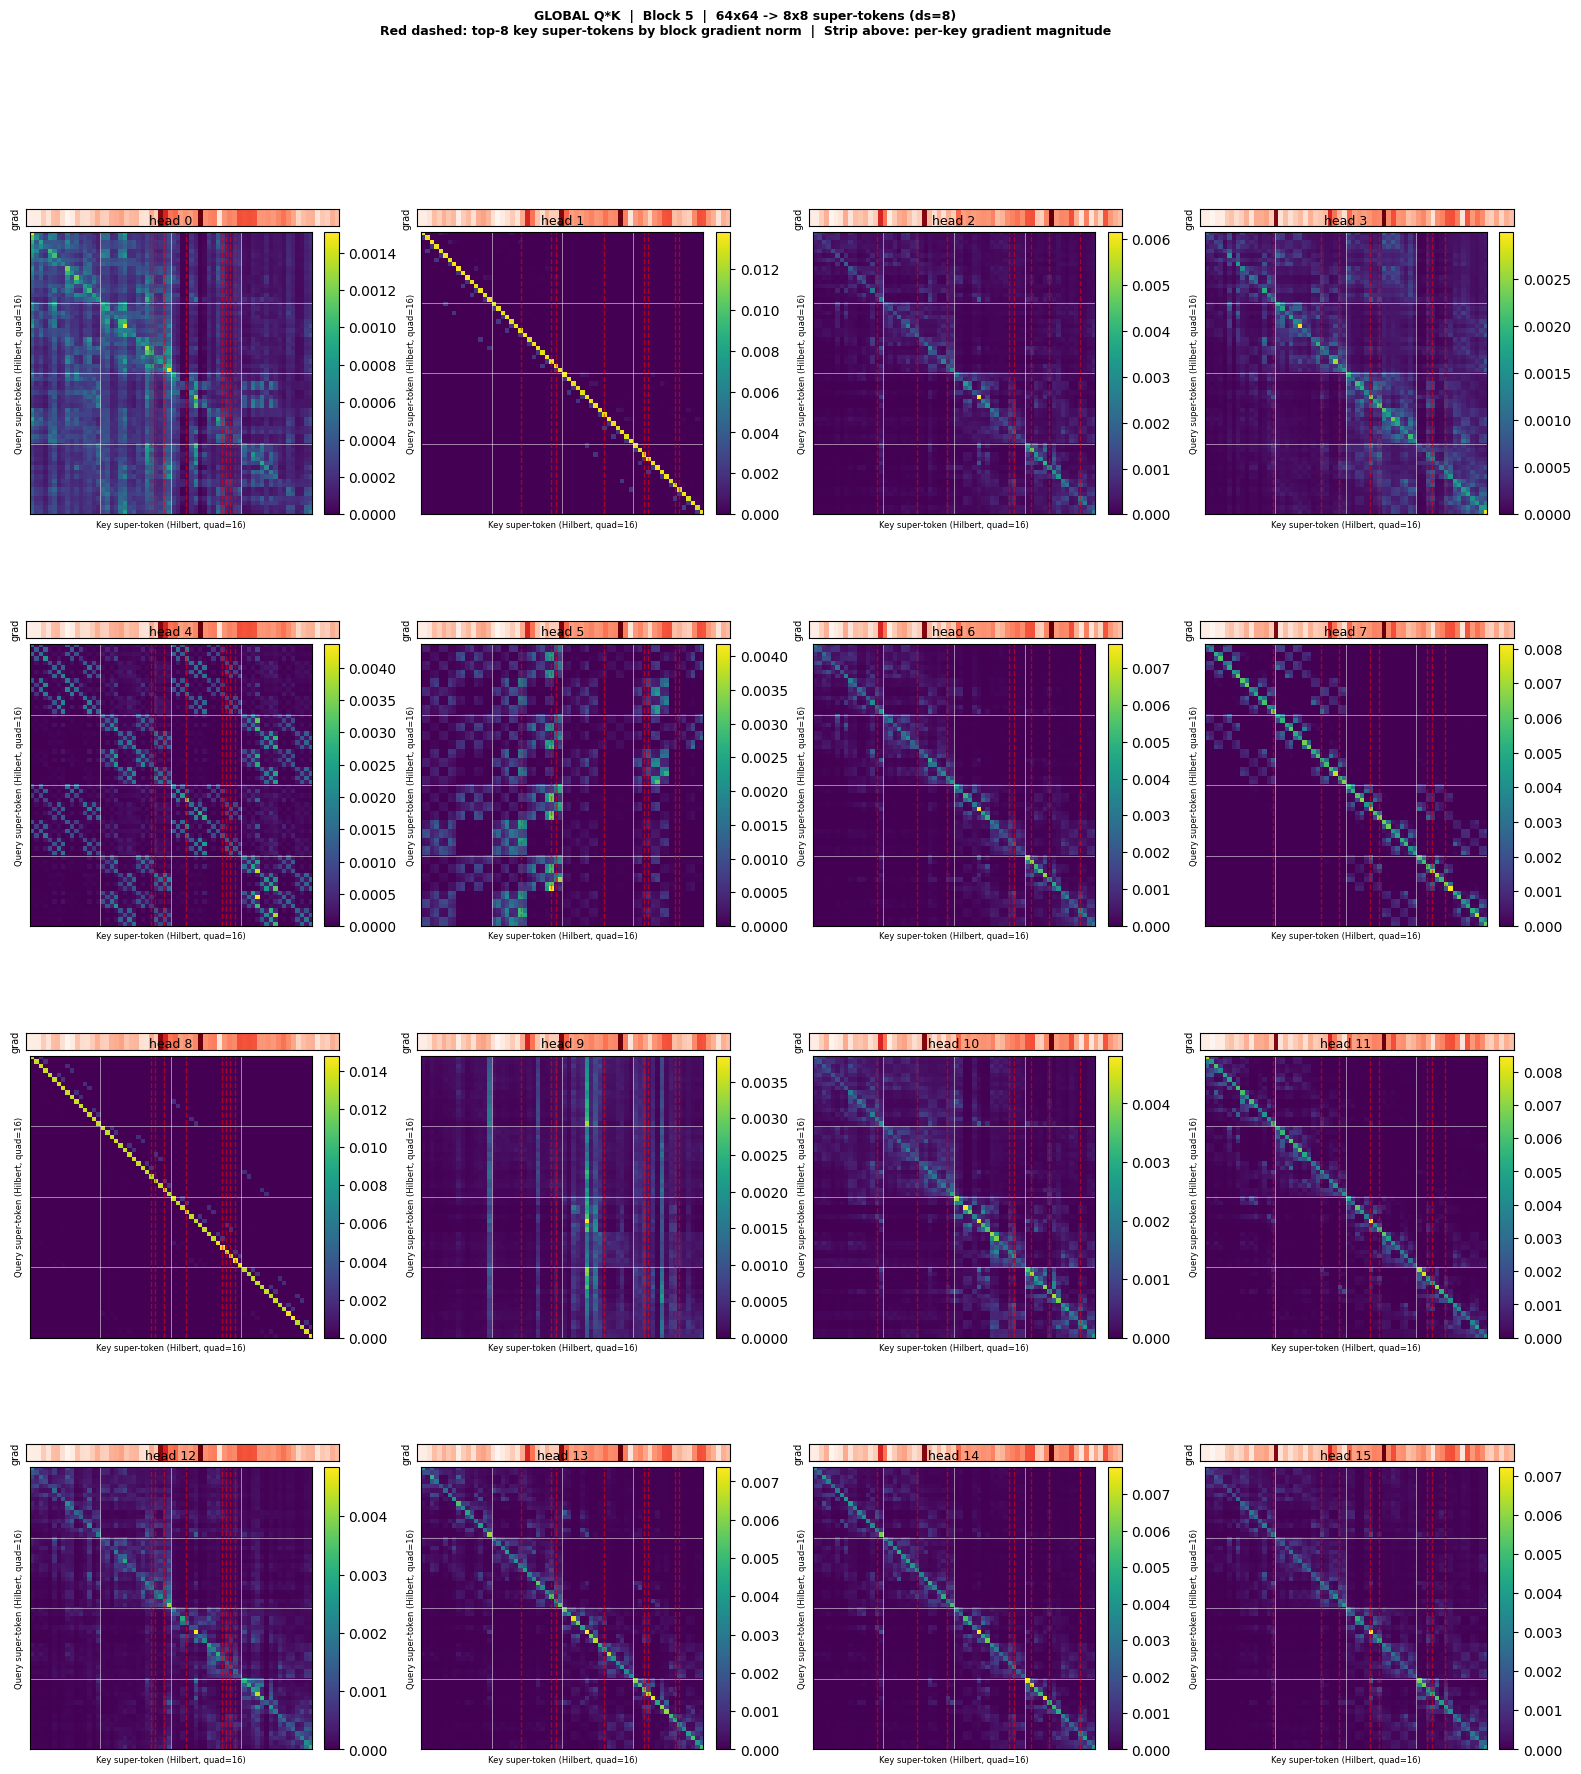

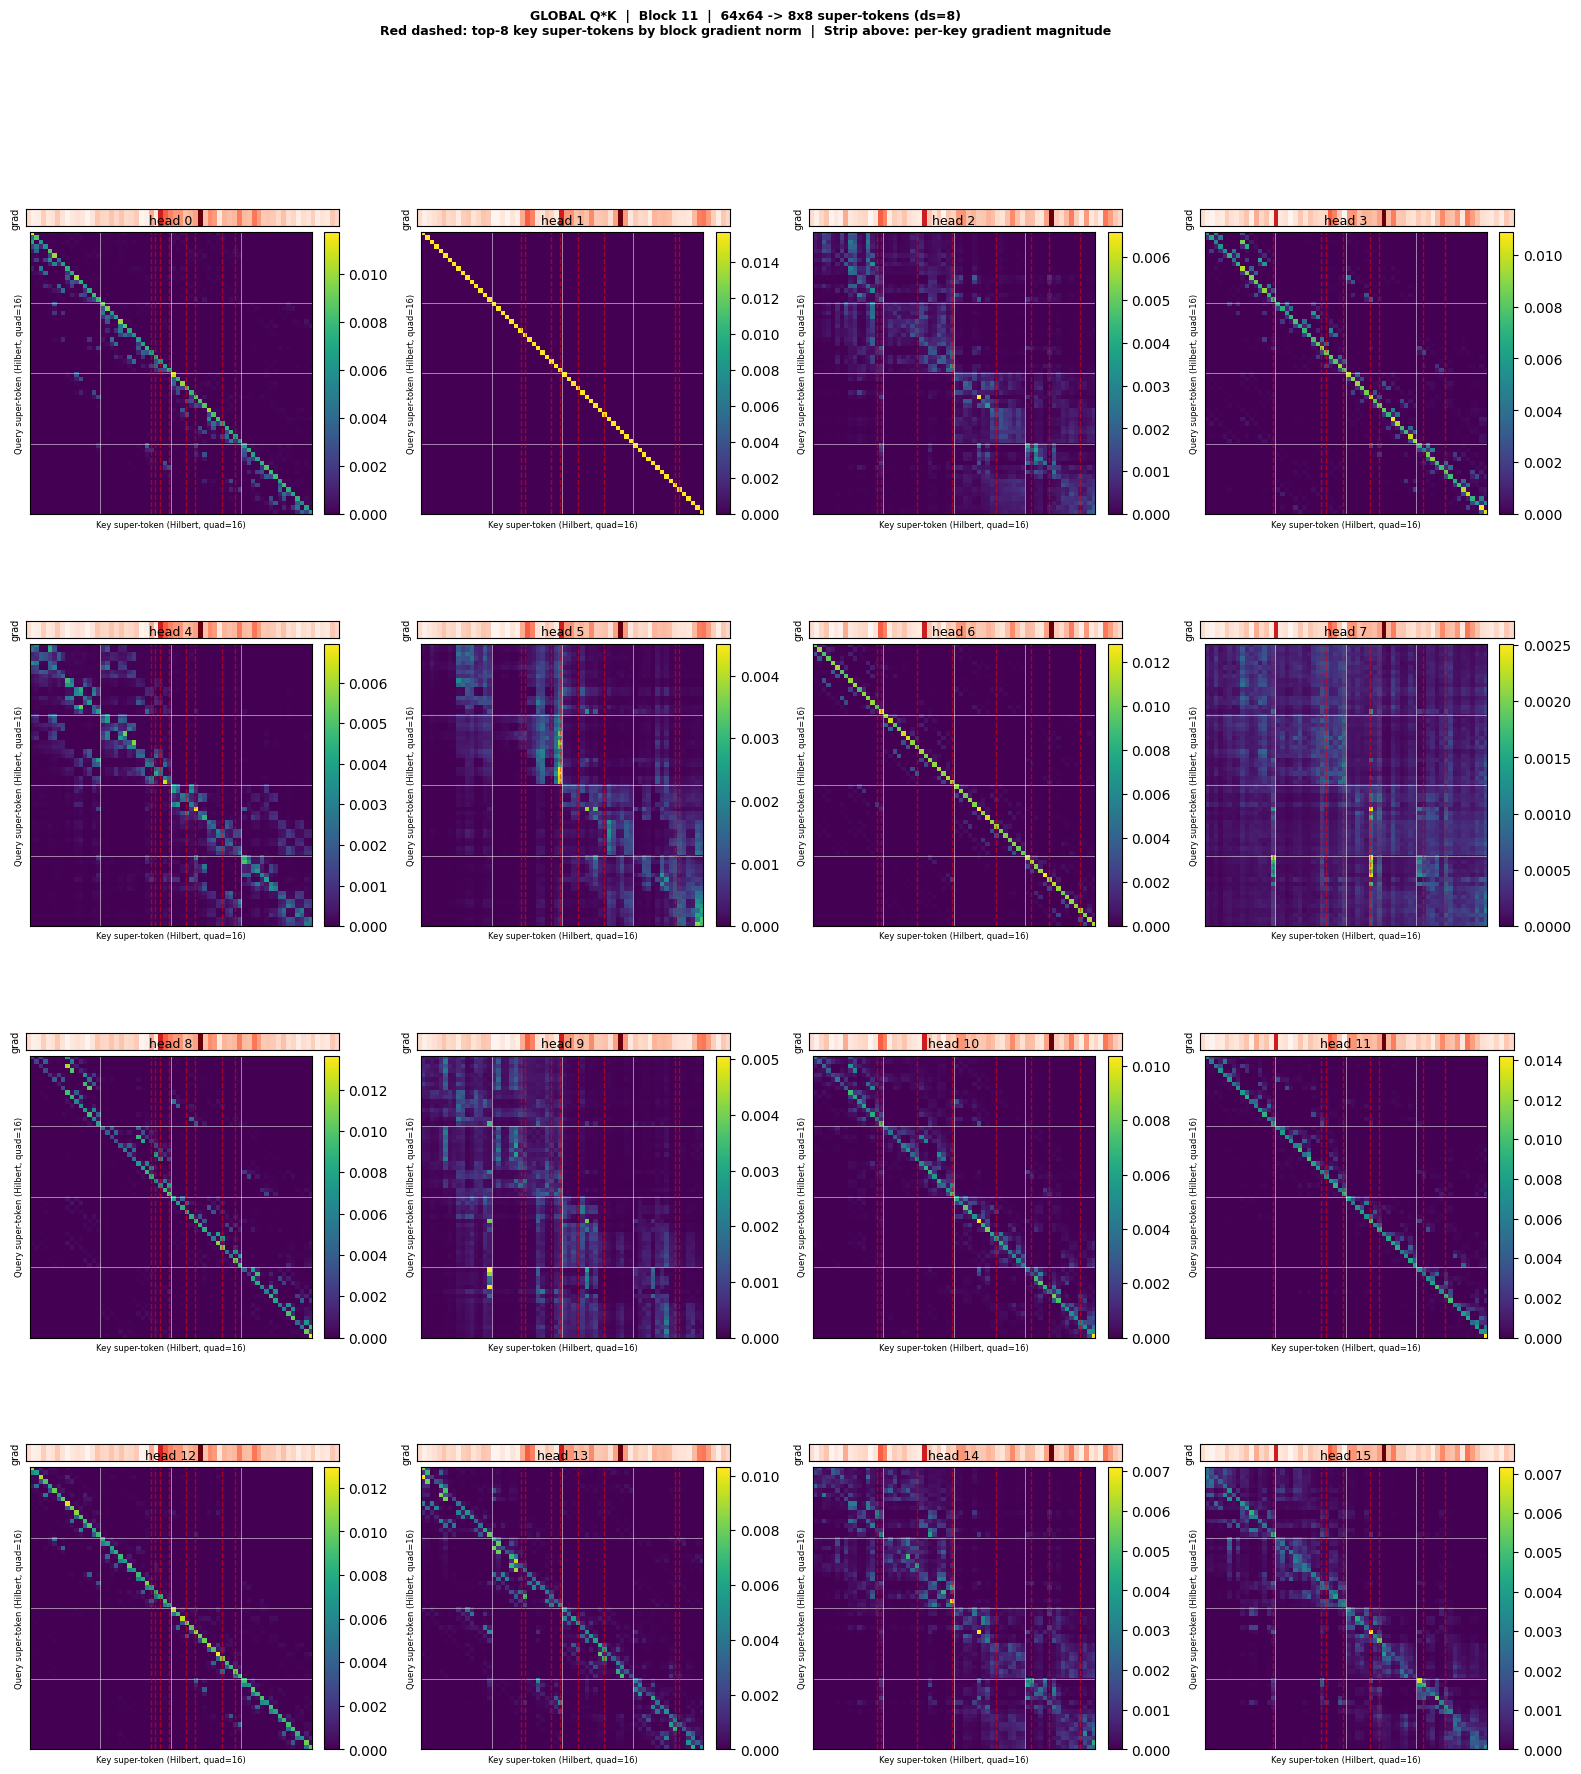

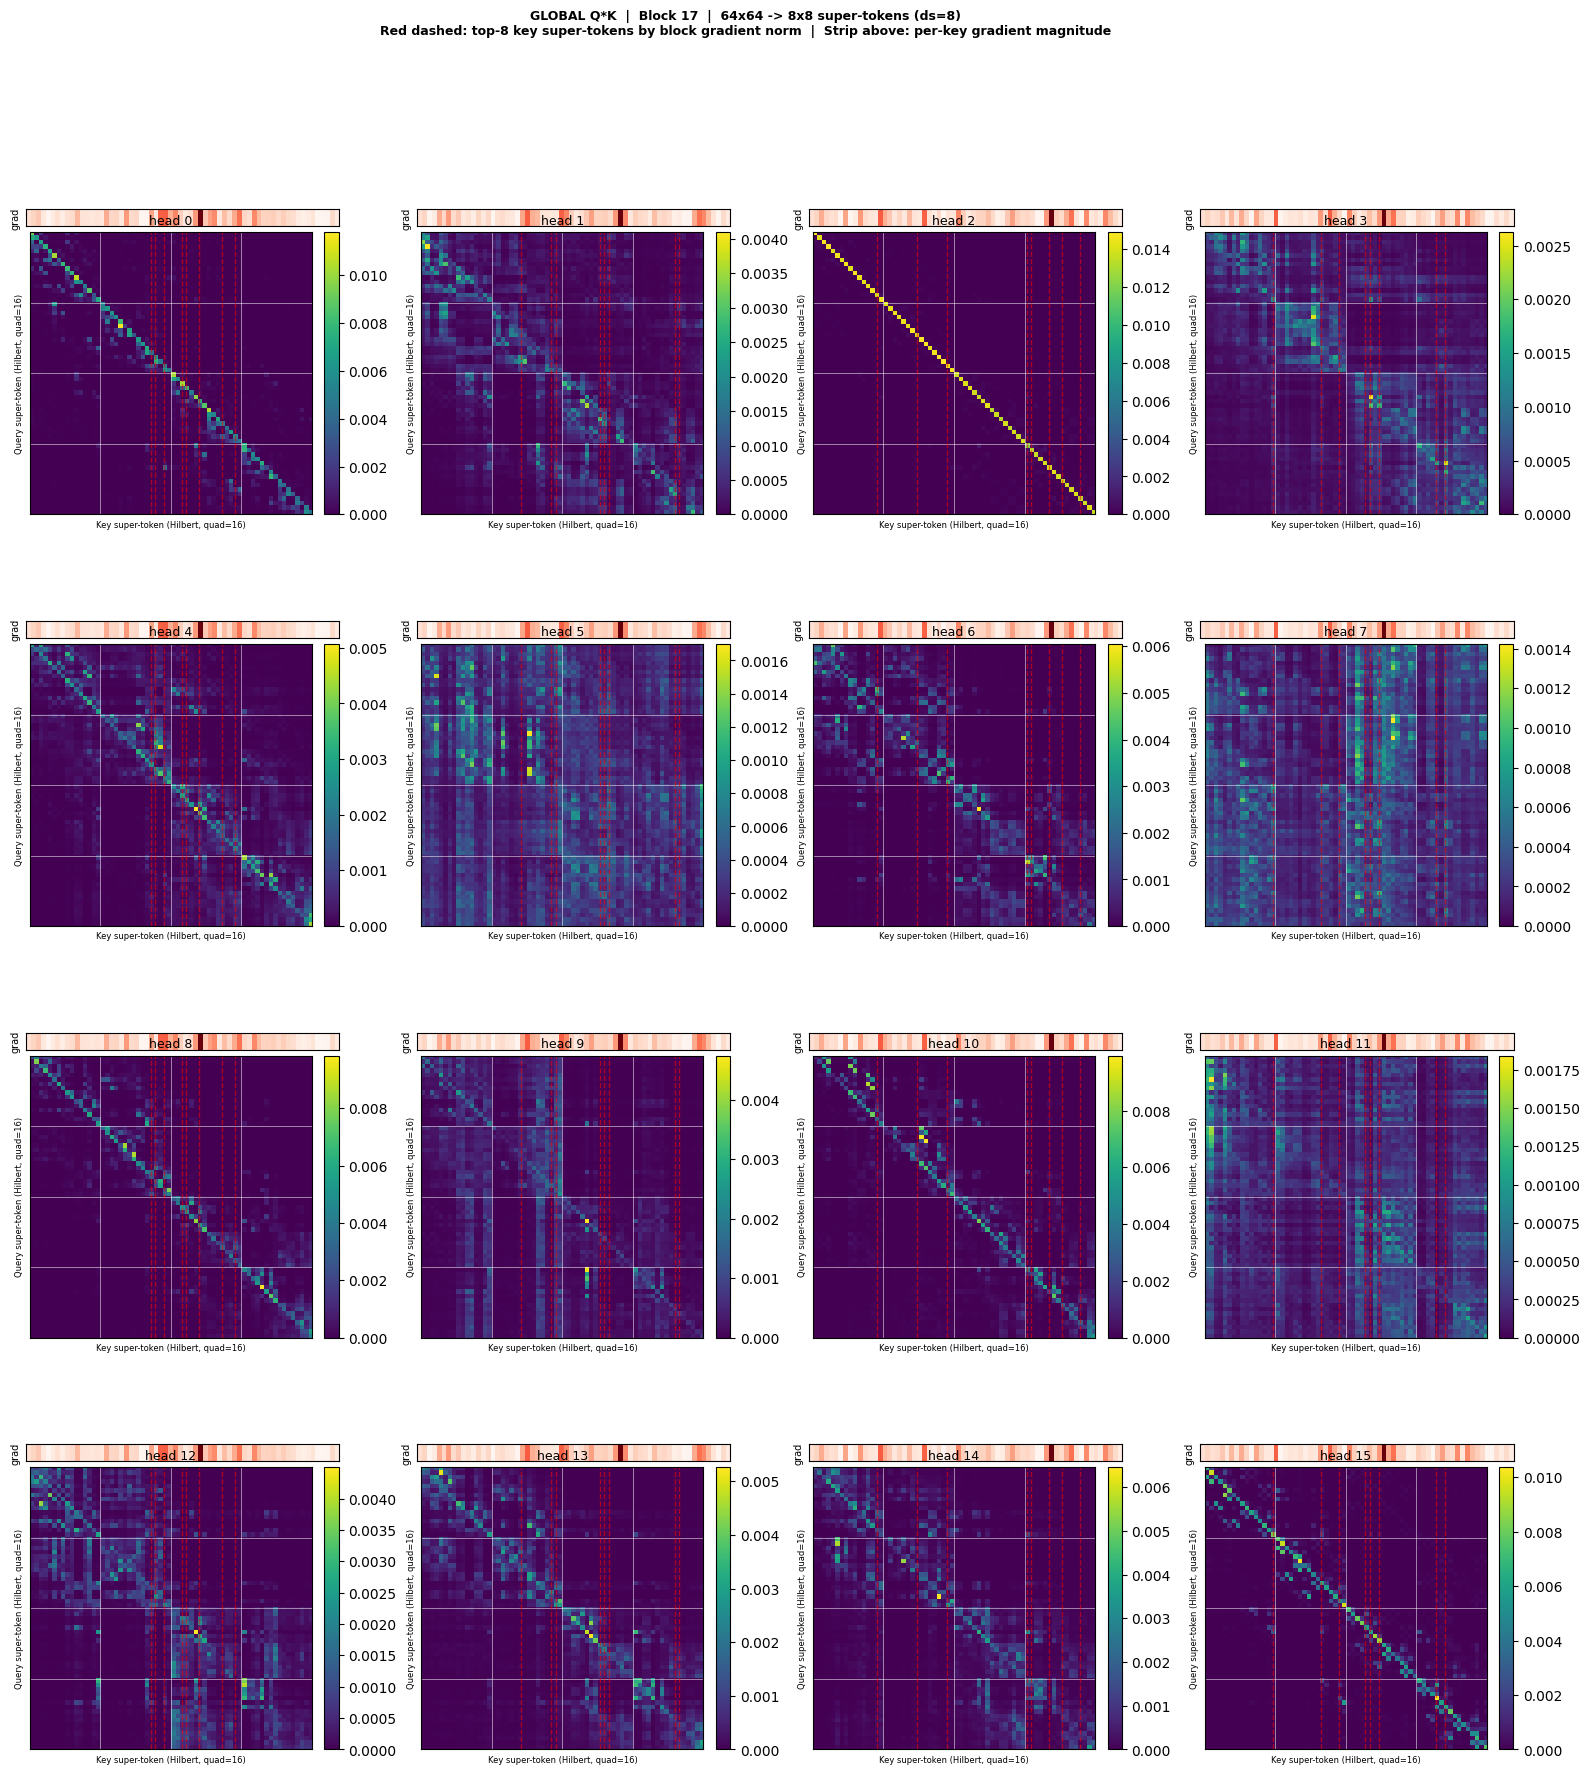

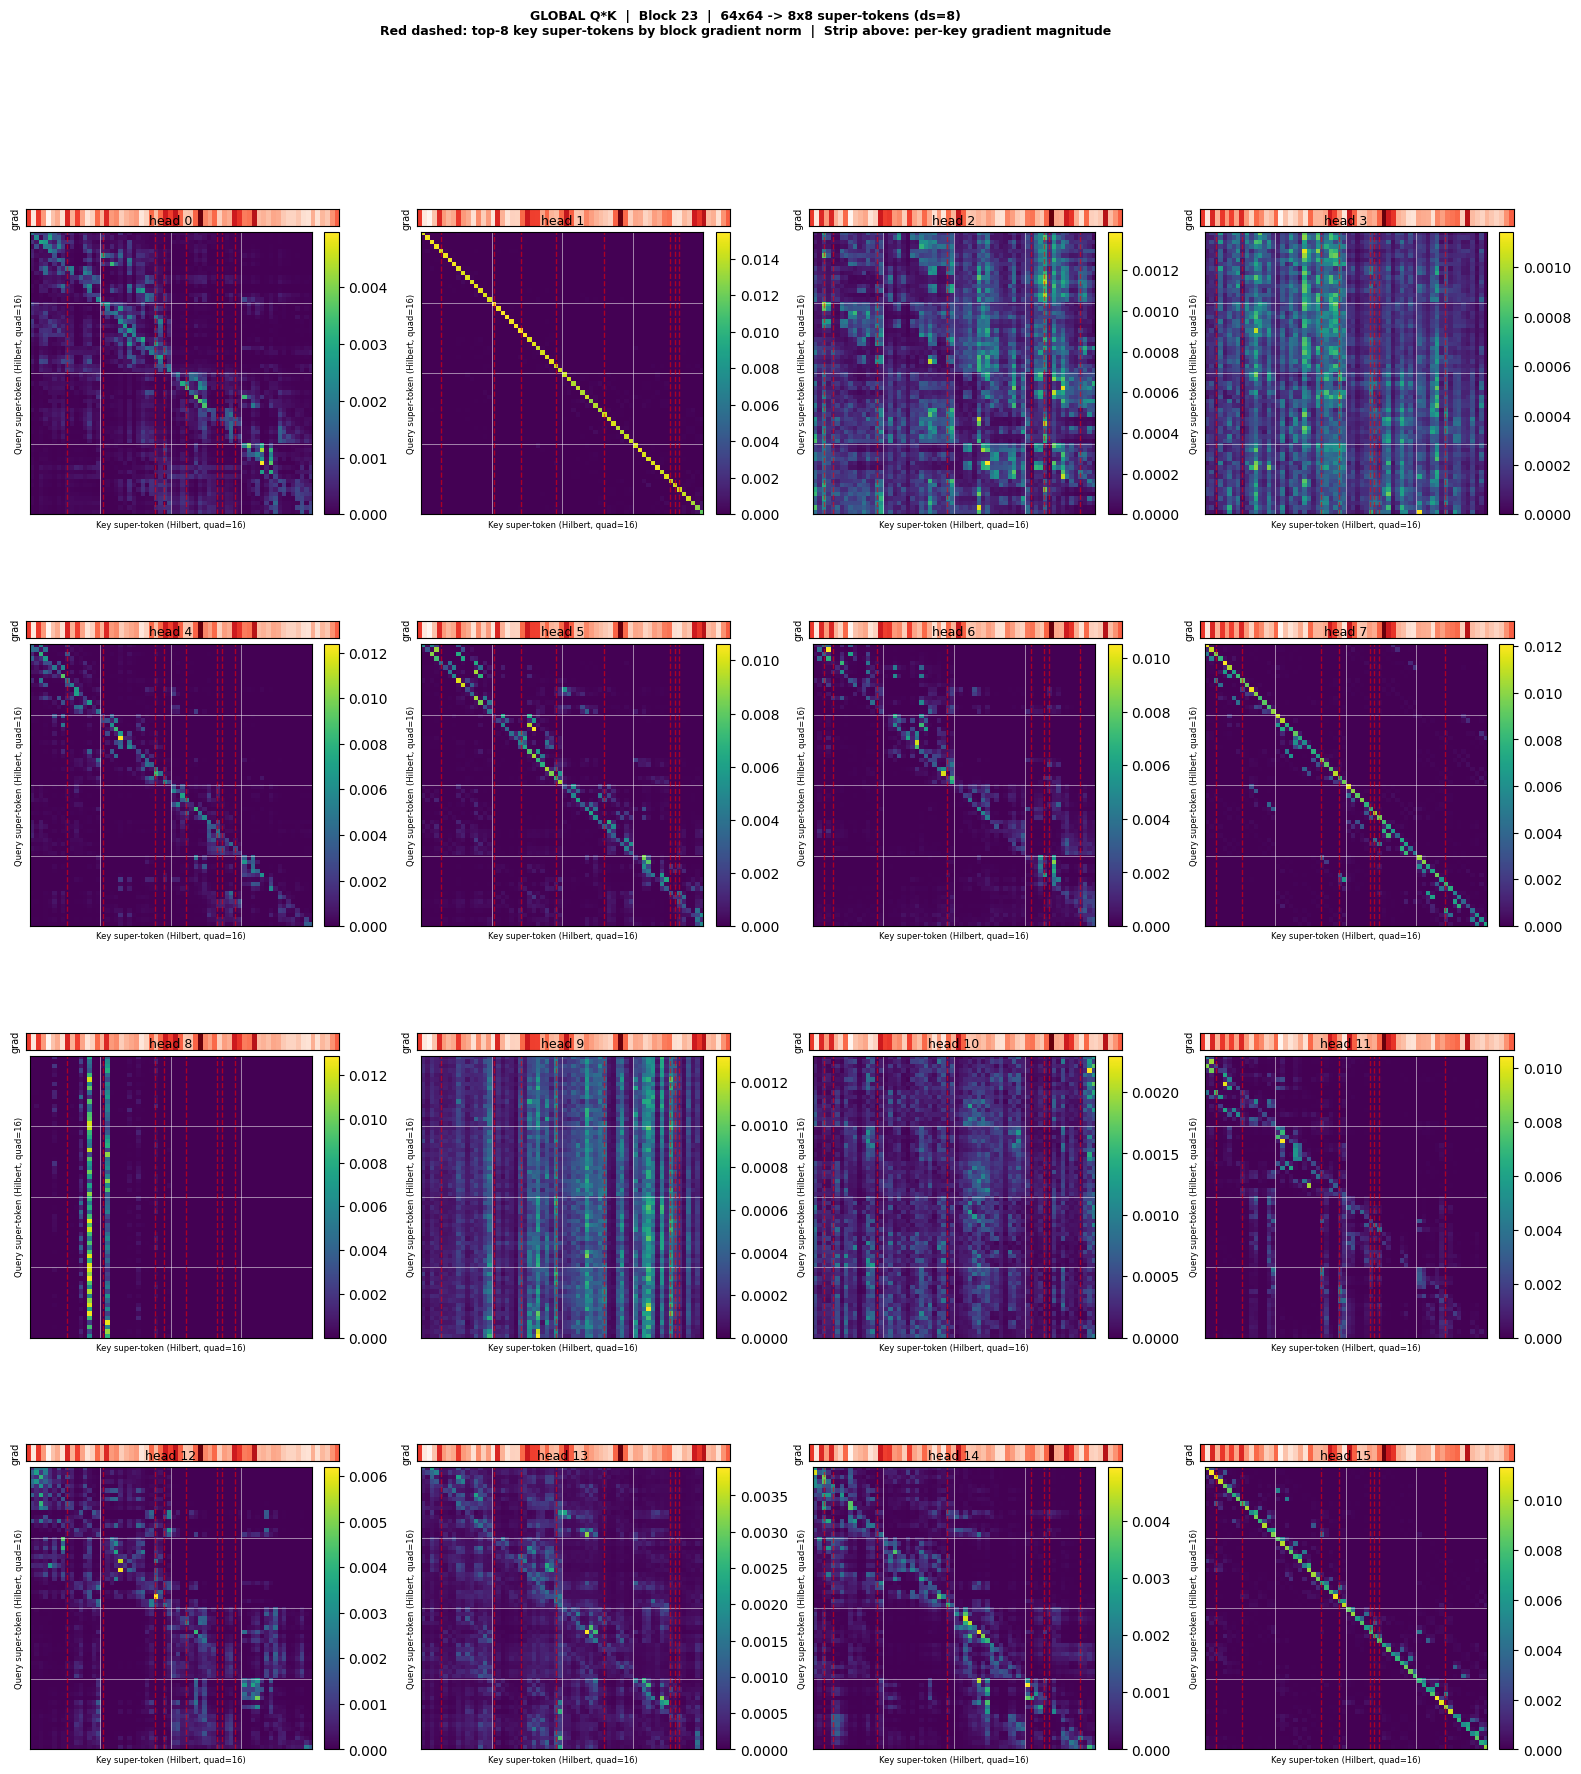

In [16]:
# ── Step 1: Sobel gradient magnitude per token at each global block ──────────
# Uses the already-captured block_inputs_cs: compute per-token mean |activation|,
# then Sobel edge magnitude as the token saliency signal (no backward pass needed).
from algo.sparsesam.z_utils import get_z_order, get_z_inverse

_bwd_grads = {}   # block_idx -> (H, W) float32 Sobel magnitude array

for _idx in range(len(block_inputs_cs)):
    _t = block_inputs_cs[_idx][0].float()           # (H, W, C)
    _H, _W = _t.shape[:2]
    _mag = _t.abs().mean(dim=-1).numpy().astype('float32')  # (H, W)
    _sx  = cv2.Sobel(_mag, cv2.CV_32F, 1, 0, ksize=3)
    _sy  = cv2.Sobel(_mag, cv2.CV_32F, 0, 1, ksize=3)
    _bwd_grads[_idx] = np.sqrt(_sx**2 + _sy**2)     # (H, W)

print('Sobel gradient computed for all blocks:')
for _idx in global_blks:
    g = _bwd_grads[_idx]
    print(f'  Block {_idx}: shape={g.shape}  max={g.max():.4f}  mean={g.mean():.4f}')


# ── Step 2: plot attention maps with high-gradient key columns overlaid ────────

def plot_global_qk_with_grad(block_idx, ds=8, cmap='viridis', top_k=8):
    ns = _attn_store[block_idx]
    nh, H, W = ns.nh, ns.H, ns.W
    assert H % ds == 0 and W % ds == 0
    Hd, Wd = H // ds, W // ds
    N = Hd * Wd

    # Block-average attention: (nh, H*W, H*W) -> (nh, N, N)
    a_raw = ns.attn.reshape(nh, Hd, ds, Wd, ds, Hd, ds, Wd, ds)
    a_ds  = a_raw.mean(dim=[2, 4, 6, 8]).reshape(nh, N, N)

    # Reorder both Q and K axes by Hilbert curve on the Hd x Wd super-token grid
    hilbert_st = get_z_order(Hd, Wd)   # (N,) raster->Hilbert index
    hilbert_inv = get_z_inverse(Hd, Wd)   # (N,) raster->Hilbert index
    a_ds = a_ds[:, :, hilbert_st][:, hilbert_st, :]  # (nh, N, N) Hilbert Q x Hilbert K

    # Per-super-token gradient: (H, W) -> (Hd, ds, Wd, ds) -> mean -> (N,)
    grad_col = None
    if block_idx in _bwd_grads:
        g_full = _bwd_grads[block_idx]                             # (H, W)
        g_ds   = (torch.from_numpy(g_full)
                      .reshape(Hd, ds, Wd, ds)
                      .mean(dim=[1, 3])
                      .reshape(N).numpy())
        g_ds_h   = g_ds[hilbert_st]   # reorder to match Hilbert K axis
        grad_col = (g_ds_h - g_ds_h.min()) / (g_ds_h.max() - g_ds_h.min() + 1e-8)

    ncols = 4
    nrows = math.ceil(nh / ncols)
    quad  = N // 4

    fig = plt.figure(figsize=(ncols * 4.8, nrows * 5.0))
    outer_gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.35, wspace=0.25)

    for h in range(nh):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer_gs[h // ncols, h % ncols],
            height_ratios=[0.06, 1], hspace=0.04,
        )
        ax_grad = fig.add_subplot(inner[0])
        ax_attn = fig.add_subplot(inner[1])

        a_h = a_ds[h].numpy()
        im  = ax_attn.imshow(a_h, cmap=cmap, interpolation='nearest',
                             aspect='equal', vmin=0)
        for g in range(quad, N, quad):
            ax_attn.axhline(g - 0.5, color='white', lw=0.6, alpha=0.6)
            ax_attn.axvline(g - 0.5, color='white', lw=0.6, alpha=0.6)

        if grad_col is not None:
            grad_col = grad_col[hilbert_inv]
            top_cols = np.argsort(grad_col)[-top_k:]
            for col_idx in top_cols:
                ax_attn.axvline(col_idx, color='red', lw=1.0,
                                alpha=0.55, linestyle='--')
            
            ax_grad.imshow(grad_col[None, :], cmap='Reds', vmin=0, vmax=1,
                           aspect='auto', interpolation='nearest')
            ax_grad.set_xlim(-0.5, N - 0.5)
            ax_grad.set_xticks([]); ax_grad.set_yticks([])
            ax_grad.set_ylabel('grad', fontsize=7)
        else:
            ax_grad.axis('off')

        ax_attn.set_title(f'head {h}', fontsize=9)
        ax_attn.set_xlabel(f'Key super-token (Hilbert, quad={quad})', fontsize=6)
        ax_attn.set_ylabel(f'Query super-token (Hilbert, quad={quad})', fontsize=6)
        ax_attn.set_xticks([]); ax_attn.set_yticks([])
        plt.colorbar(im, ax=ax_attn, fraction=0.046, pad=0.04)

    # for h in range(nh, nrows * ncols):
        # fig.add_subplot(outer_gs[h // ncols, h % ncols]).axis('off')

    ws = sam.image_encoder.blocks[block_idx].window_size
    fig.suptitle(
        f'GLOBAL Q*K  |  Block {block_idx}  '
        f'|  {H}x{W} -> {Hd}x{Wd} super-tokens (ds={ds})\n'
        f'Red dashed: top-{top_k} key super-tokens by block gradient norm  '
        f'|  Strip above: per-key gradient magnitude',
        fontsize=9, fontweight='bold',
    )
    plt.show()
    return fig


for _blk in global_blks:
    plot_global_qk_with_grad(_blk)


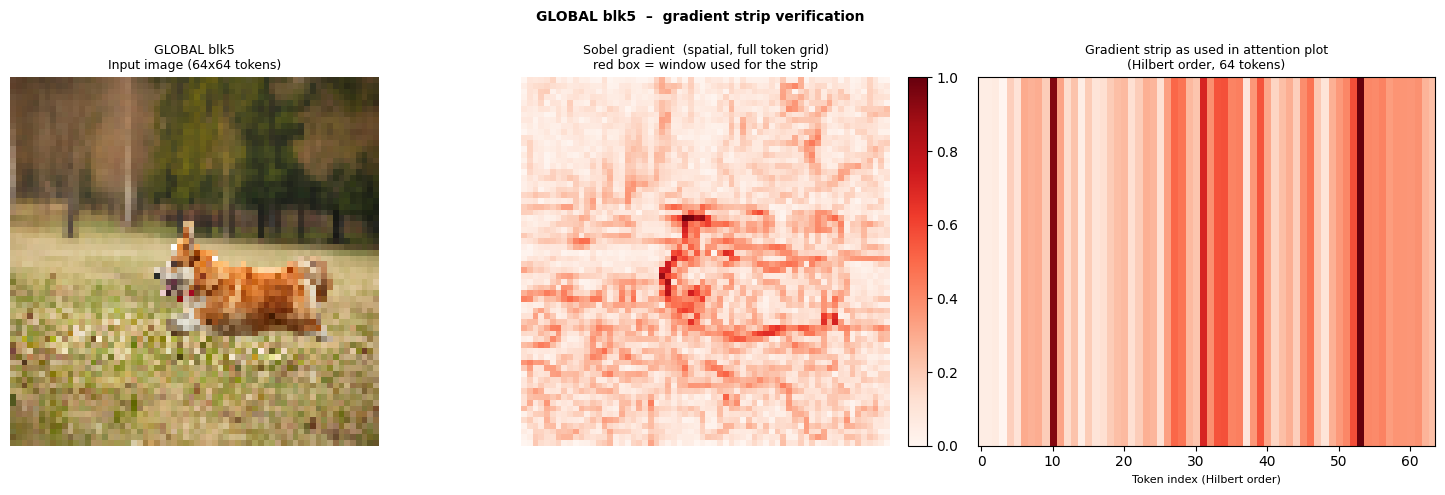

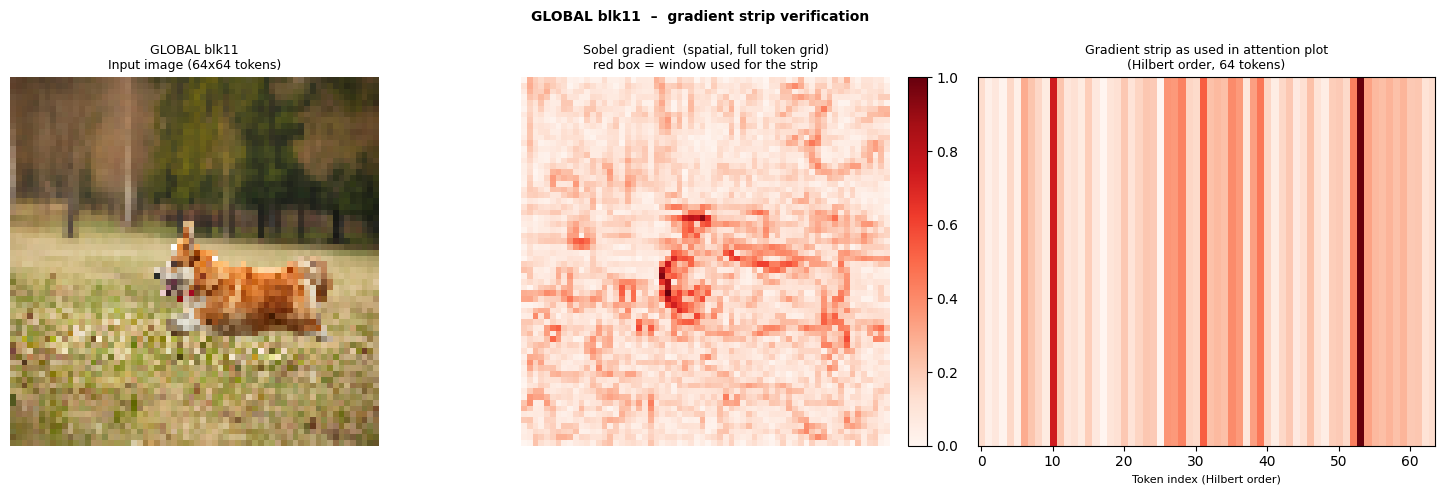

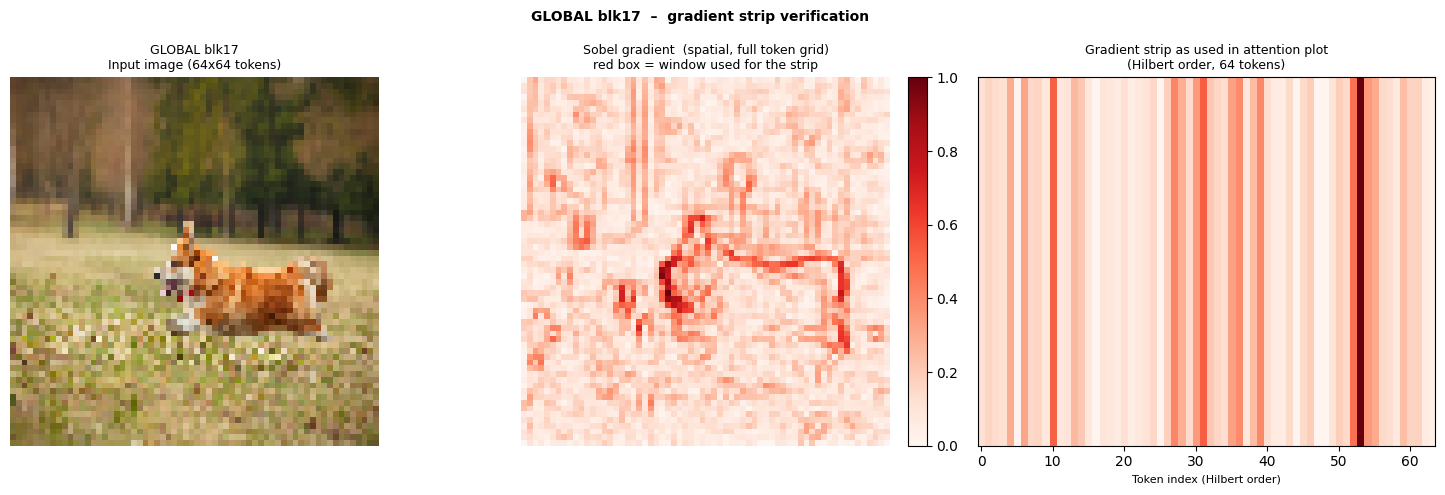

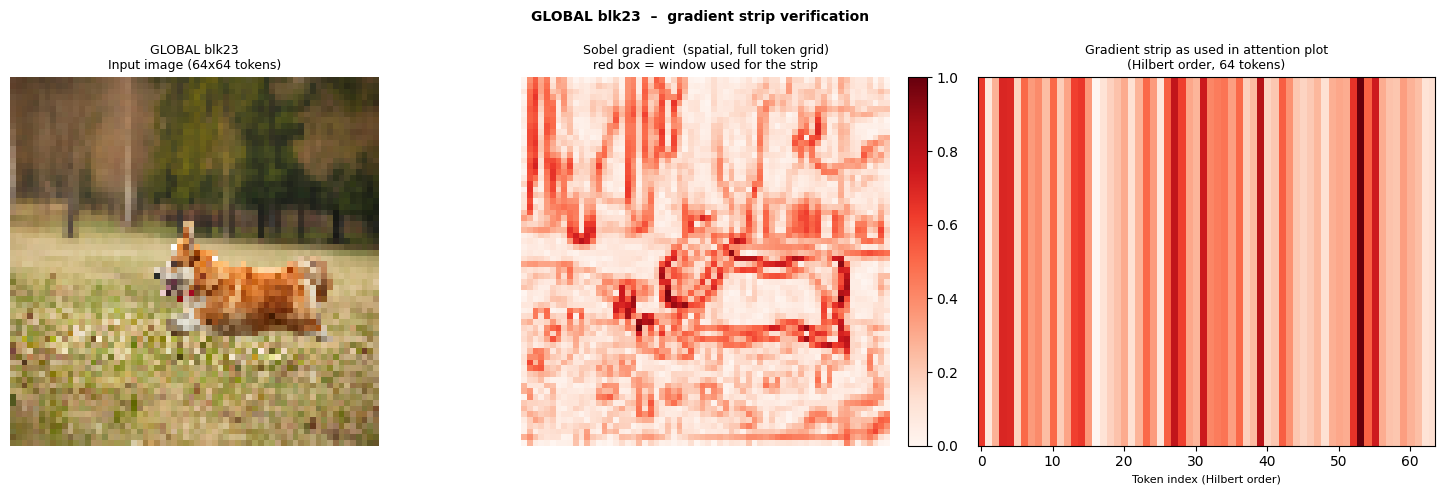

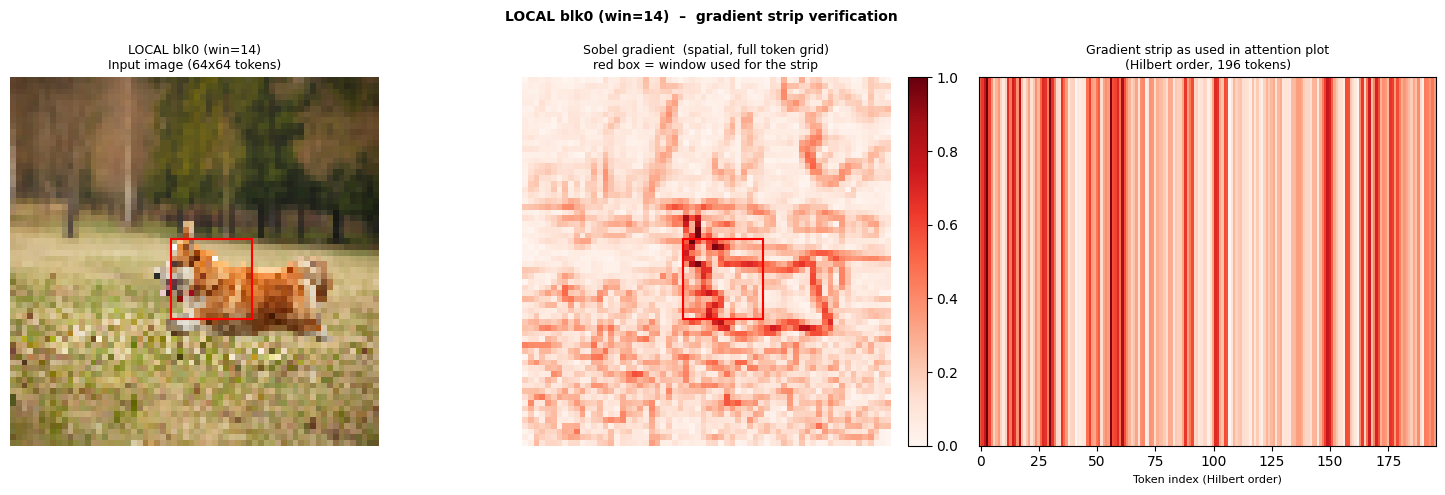

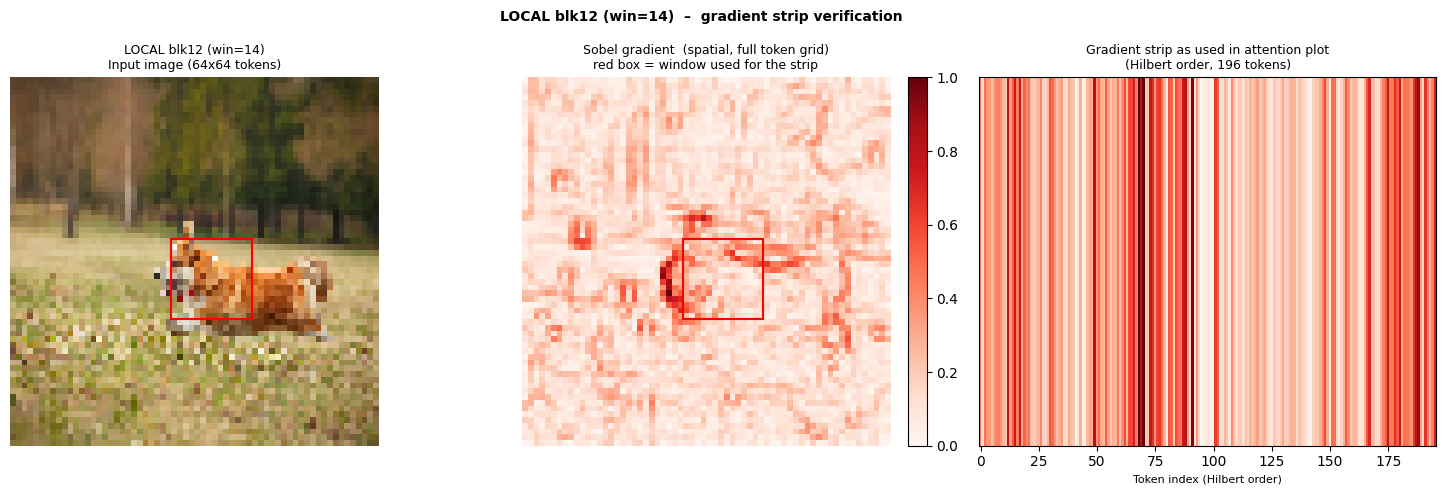

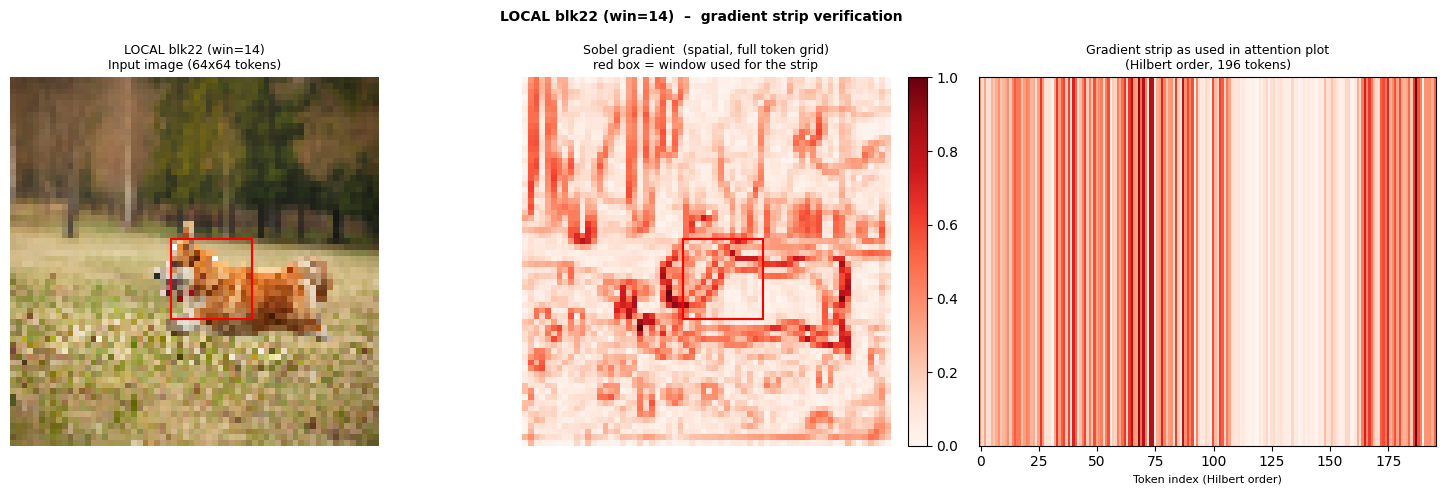

In [ ]:
_calib_bgr  = cv2.imread(IMG_PATH)
_img_small  = cv2.resize(cv2.cvtColor(_calib_bgr, cv2.COLOR_BGR2RGB),
                          (W_tok, H_tok))

def _plot_grad_spatial(block_idx, wr=None, wc=None):
    if block_idx not in _bwd_grads:
        print(f'Block {block_idx} not in _bwd_grads, skipping')
        return

    is_local = block_idx not in global_blks
    ws   = sam.image_encoder.blocks[block_idx].window_size
    tag  = f'LOCAL blk{block_idx} (win={ws})' if is_local else f'GLOBAL blk{block_idx}'

    g2d  = _bwd_grads[block_idx]          # (H_tok, W_tok)  full spatial Sobel map

    # Hilbert-reordered 1D strip (exactly what goes into the plot)
    if is_local:
        wr = nw_h // 2 if wr is None else wr
        wc = nw_w // 2 if wc is None else wc
        r0, c0 = wr * win_h, wc * win_w
        g_win   = g2d[r0:r0+win_h, c0:c0+win_w].copy()  # (win_h, win_w)
        HW      = win_h * win_w
        hilbert = get_hilbert_order(win_h, win_w)
        g_1d    = g_win.reshape(-1)[hilbert]              # (HW,) Hilbert order
    else:
        ns      = _attn_store[block_idx]
        H, W    = ns.H, ns.W
        Hd, Wd  = H // 8, W // 8                         # ds=8 super-tokens
        N       = Hd * Wd
        g_ds    = (torch.from_numpy(g2d)
                       .reshape(Hd, 8, Wd, 8)
                       .mean(dim=[1, 3])
                       .reshape(N).numpy())
        hilbert = get_hilbert_order(Hd, Wd)
        g_1d    = g_ds[hilbert]                           # (N,) Hilbert order
        HW      = N

    # Normalise
    g2d_n  = (g2d  - g2d.min())  / (g2d.max()  - g2d.min()  + 1e-8)
    g1d_n  = (g_1d - g_1d.min()) / (g_1d.max() - g_1d.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # col 0: input image at token resolution
    axes[0].imshow(_img_small)
    if is_local:
        from matplotlib.patches import Rectangle
        axes[0].add_patch(Rectangle(
            (c0 - 0.5, r0 - 0.5), win_w, win_h,
            linewidth=1.5, edgecolor='red', facecolor='none'))
    axes[0].set_title(f'{tag}\nInput image ({H_tok}x{W_tok} tokens)', fontsize=9)
    axes[0].axis('off')

    # col 1: full 2D Sobel spatial map
    im1 = axes[1].imshow(g2d_n, cmap='Reds', vmin=0, vmax=1,
                          interpolation='nearest', aspect='equal')
    if is_local:
        from matplotlib.patches import Rectangle as Rect
        axes[1].add_patch(Rect(
            (c0 - 0.5, r0 - 0.5), win_w, win_h,
            linewidth=1.5, edgecolor='red', facecolor='none'))
    axes[1].set_title('Sobel gradient  (spatial, full token grid)\n'
                      'red box = window used for the strip', fontsize=9)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # col 2: the 1D strip (Hilbert order) as a horizontal bar
    axes[2].imshow(g1d_n[None, :], cmap='Reds', vmin=0, vmax=1,
                   aspect='auto', interpolation='nearest')
    axes[2].set_title(
        f'Gradient strip as used in attention plot\n'
        f'(Hilbert order, {HW} tokens)', fontsize=9)
    axes[2].set_yticks([])
    axes[2].set_xlabel('Token index (Hilbert order)', fontsize=8)

    plt.suptitle(tag + '  –  gradient strip verification', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Global blocks
for _blk in global_blks:
    _plot_grad_spatial(_blk)

# Local blocks (first, middle, last)
for _blk in [local_blks[0], local_blks[len(local_blks) // 2], local_blks[-1]]:
    _plot_grad_spatial(_blk)


In [ ]:
from einops import rearrange
import torch
x = torch.arange(0, 12).reshape(3,4)
y = x.T.reshape(-1)

In [ ]:
y

tensor([ 0,  4,  8,  1,  5,  9,  2,  6, 10,  3,  7, 11])

## 7 – Vertical bar sparse mask visualization

Shows the block-sparse attention pattern for different sparsity levels.
For each sparsity value, a vertical bar of width `⌈(1−sparsity) × n_block_max⌉` blocks
is centered in the key sequence — every query block attends to the same set of key blocks.

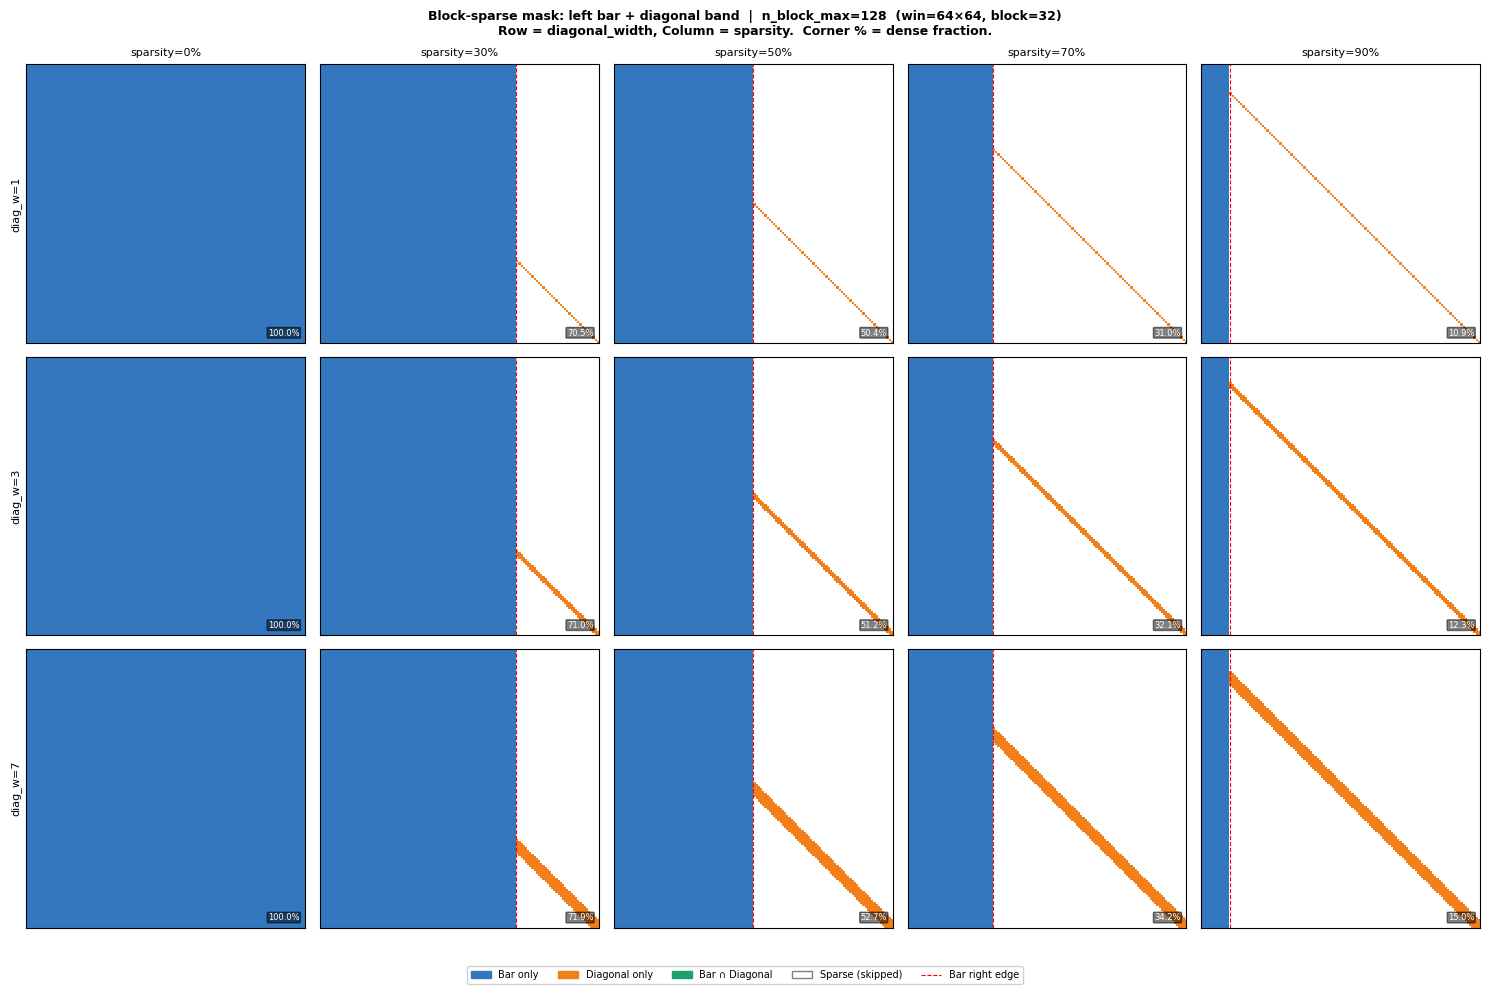

In [19]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Encoder geometry ──────────────────────────────────────────────────────────
_FA2_N_BLOCK  = 32

global_blk_0 = next(b for b in sam.image_encoder.blocks if b.window_size == 0)
win          = global_blk_0.attn.rel_pos_h.shape[1]
Sq           = win * win
n_block_max  = math.ceil(Sq / _FA2_N_BLOCK)   # e.g. 128 for vit_l


# ── Mask computation (mirrors kernel exactly) ─────────────────────────────────
def make_mask(n_block_max: int, sparsity: float = 0.0, diagonal_width: int = 1):
    """
    Returns (n_block_max × n_block_max) uint8 mask with:
      1 = dense  (bar OR diagonal band)
      0 = sparse (skipped)
    """
    bar_density = 1.0 - sparsity
    bar_pct     = round(bar_density * 1000)
    bar_width   = math.ceil(n_block_max * bar_pct / 1000)
    n_bar_end   = min(bar_width, n_block_max)

    diag_radius = (diagonal_width - 1) // 2

    mask = np.zeros((n_block_max, n_block_max), dtype=np.uint8)
    # Left bar (all rows)
    mask[:, :n_bar_end] = 1
    # Diagonal band (per row)
    for m in range(n_block_max):
        d_end = min(n_block_max, m + diag_radius + 1)
        d_start = max(0, m - diag_radius)
        mask[m, d_start:d_end] = 1

    return mask, n_bar_end, diag_radius


# ── Plot: vary sparsity and diagonal_width ────────────────────────────────────
sparsity_levels  = [0.0, 0.3, 0.5, 0.7, 0.9]
diagonal_widths  = [1, 3, 7]

nrows = len(diagonal_widths)
ncols = len(sparsity_levels)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 3.2))

for ri, dw in enumerate(diagonal_widths):
    for ci, sp in enumerate(sparsity_levels):
        ax = axes[ri, ci]
        mask, n_bar_end, dr = make_mask(n_block_max, sp, dw)

        # Base image: white=sparse, blue=bar, orange=diagonal-only
        rgb = np.ones((n_block_max, n_block_max, 3))  # white
        bar_only  = np.zeros((n_block_max, n_block_max), bool)
        diag_only = np.zeros((n_block_max, n_block_max), bool)
        both      = np.zeros((n_block_max, n_block_max), bool)

        bar_mask  = np.zeros_like(mask)
        bar_mask[:, :n_bar_end] = 1
        diag_mask = mask - bar_mask
        diag_mask = np.clip(diag_mask, 0, 1)

        bar_only  = (bar_mask == 1) & (diag_mask == 0)
        diag_only = (diag_mask == 1) & (bar_mask == 0)
        both      = (bar_mask == 1) & (diag_mask == 1)

        rgb[bar_only]  = [0.20, 0.47, 0.75]   # blue  – bar only
        rgb[diag_only] = [0.95, 0.50, 0.10]   # orange – diagonal only
        rgb[both]      = [0.12, 0.63, 0.42]   # green – overlap

        ax.imshow(rgb, interpolation='nearest', aspect='equal', origin='upper')

        # Bar edge
        if n_bar_end < n_block_max:
            ax.axvline(n_bar_end - 0.5, color='red', lw=0.8, ls='--')

        if ri == 0:
            ax.set_title(f'sparsity={sp:.0%}', fontsize=8)
        if ci == 0:
            ax.set_ylabel(f'diag_w={dw}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

        # Density annotation
        density = mask.sum() / mask.size
        ax.text(0.98, 0.02, f'{density:.1%}', transform=ax.transAxes,
                fontsize=6, ha='right', va='bottom', color='white',
                bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.5))

legend_patches = [
    mpatches.Patch(color=(0.20, 0.47, 0.75), label='Bar only'),
    mpatches.Patch(color=(0.95, 0.50, 0.10), label='Diagonal only'),
    mpatches.Patch(color=(0.12, 0.63, 0.42), label='Bar ∩ Diagonal'),
    mpatches.Patch(color='white', ec='grey', label='Sparse (skipped)'),
    plt.Line2D([0], [0], color='red', ls='--', lw=0.8, label='Bar right edge'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=7, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    f'Block-sparse mask: left bar + diagonal band  |  '
    f'n_block_max={n_block_max}  (win={win}×{win}, block={_FA2_N_BLOCK})\n'
    f'Row = diagonal_width, Column = sparsity.  Corner % = dense fraction.',
    fontsize=9, fontweight='bold',
)
plt.tight_layout()
plt.show()

In [10]:
from cutlass.cute.runtime import from_dlpack
def make_A_mask(B, H, T, ratio, m_block, n_block,
                band_width: int = 1,
                keep_bar_scale: float = 1.0,
                device="cuda"):
    num_m_blocks = math.ceil(T / m_block)
    num_n_blocks = math.ceil(T / n_block)

    t = torch.zeros(B, H, num_m_blocks, num_n_blocks, dtype=torch.int32, device=device)

    # Banded diagonal of width `band_width` (centered on the identity).
    half = band_width // 2
    for k in range(-half, band_width - half):
        if k == 0:
            i_m = torch.arange(min(num_m_blocks, num_n_blocks), device=device)
            t[:, :, i_m, i_m] = 1
        else:
            i_m = torch.arange(max(0, -k), min(num_m_blocks, num_n_blocks - k), device=device)
            t[:, :, i_m, i_m + k] = 1

    # Reduced vertical "keep" bar.
    n_keep_cols = int(ratio * num_n_blocks * keep_bar_scale)
    if n_keep_cols > 0:
        t[:, :, :, :(n_keep_cols - band_width +1 ) ] = 1

    ct = from_dlpack(t, assumed_align=4)
    return ct, t

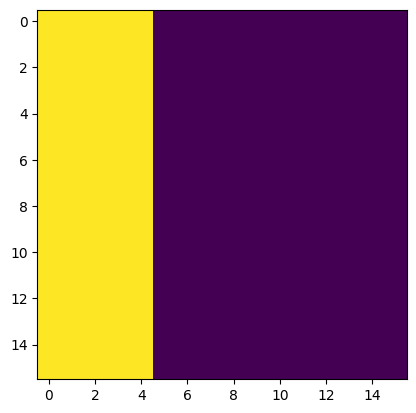

: 

In [ ]:
from matplotlib import pyplot as plt
import math
import torch
B =  1
H =  16
T =  256 
ratio = 0.25
m_block  =  16 
n_block  =  16  
band = 0 
plt.imshow(make_A_mask(B, H, T, ratio, m_block, n_block, band_width=band)[1][0,0].cpu().numpy())